# Achievement First Director of Data Analysis Exercise
---

**Please save your own copy of the collab so that you can edit it.**

## Background

Use any resources (Google, Stack Overflow) that would be helpful to complete the tasks. On the second task, use any packages you are most comfortable with and be prepared to talk through your choices. We appreciate you taking the time to complete this exercise.

If you have any questions, please reach out to meaghanross@achievementfirst.org.

## Task 1: SQL

Achievement First needs your help urgently! Due to a massive data loss, we tragically could only gain access to a limited number of tables from our Student Information System, Infinite Campus. The database contains the following tables:

1. calendar.csv
2. person.csv
3. enrollment.csv
4. school.csv
5. schoolyear.csv

Below is the schema doc describing the relationship between the tables.

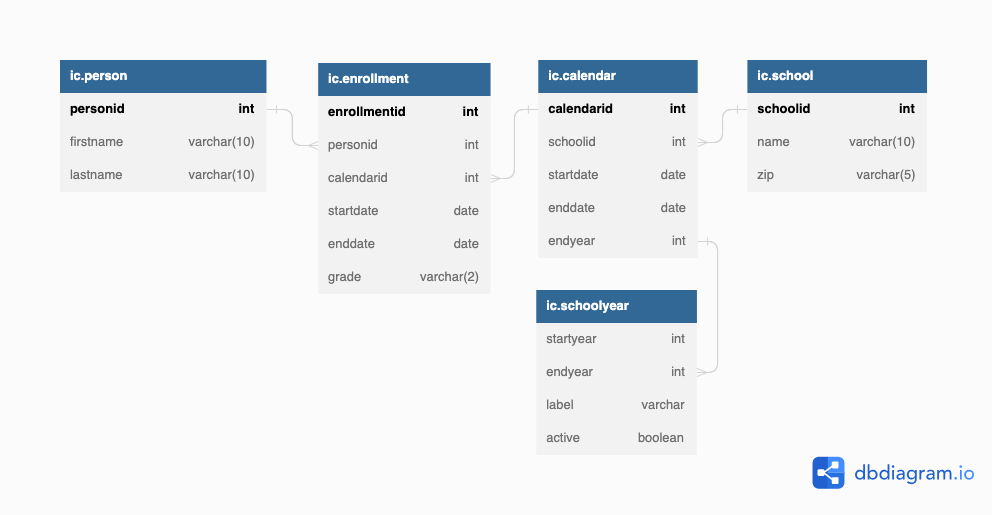


### Answer the following questions about student enrollment using sql.

- How many unique students are enrolled in the active school year? (Note: active school year should be set to end year 2020)
- How many students were enrolled in school bp as of 10/1/2019? (that is startdate is on or before 10/1 and enddate is after 10/1)
- Who are the 3 students with the most recent startdate of the students that have multiple enrollments in the active school year?

If you believe the data we've provided is not sufficient for a task, please outline your concerns in your report with suggestions.

## Task 2: Visualize This!

Please visualize a single aspect of the data you find important. At Achievement First, the Analysis & Reporting Team uses Tableau for a majority of data visualization. For this task, you may use any data visualization tool you feel comfortable using and have access to, but Tableau Public is preferred. The enrollment data you are visualizing and analyzing should focus on endyears 2019, 2020, and 2021.
-   Why did you choose this particular visualization?
-   What would you improve in your visualization?
-   What would be your conclusions and recommendations to AF's Team Student Recruitment and Enrollment based on this visualization?


# Deliverables:
Please submit any materials you used to complete these tasks. This includes:
- A version of this notebook as a .ipynb file
- A Tableau workbook
- A pdf of a presentation or document
- A link to a github repo with any materials for these tasks


In [1]:
# Run this cell to import packages and generate funtions for SQL

import pandas as pd
import sqlite3

def df_to_sqlDB(input_df: pd.DataFrame,
                table_name: str,
                db_name: str = 'default.db') -> None:

    '''Take a Pandas dataframe `input_df` and upload it to `table_name` SQLITE table
    Args:
        input_df (pd.DataFrame): Dataframe containing data to upload to SQLITE
        table_name (str): Name of the SQLITE table to upload to
        db_name (str, optional): Name of the SQLITE Database in which the table is created.
                                 Defaults to 'default.db'.
    '''

    # Step 1: Setup local logging
    import logging
    logging.basicConfig(level=logging.INFO,
                        format='%(asctime)s %(levelname)s: %(message)s',
                        datefmt='%Y-%m-%d %H:%M:%S')

    # Step 2: Find columns in the dataframe
    cols = input_df.columns
    cols_string = ','.join(cols)
    val_wildcard_string = ','.join(['?'] * len(cols))

    # Step 3: Connect to a DB file if it exists, else create a new file
    try:
      conn = sqlite3.connect(db_name)
      cur = conn.cursor()
      logging.info(f'SQL DB {db_name} created')

      # Step 4: Create Table
      sql_string = f"""CREATE TABLE {table_name} ({cols_string});"""
      cur.execute(sql_string)
      logging.info(f'SQL Table {table_name} created with {len(cols)} columns')

      # Step 5: Upload the dataframe
      rows_to_upload = input_df.to_dict(orient='split')['data']
      sql_string = f"""INSERT INTO {table_name} ({cols_string}) VALUES ({val_wildcard_string});"""
      cur.executemany(sql_string, rows_to_upload)
      logging.info(f'{len(rows_to_upload)} rows uploaded to {table_name}')

      # Step 6: Commit the changes and close the connection
      conn.commit()
      conn.close()
    except Exception as e:
      logging.error(f"Error loading data into SQLite database: {e}")


def execute_sql_query(sql_query_string: str, db_name: str = 'default.db') -> None:
    '''
    Execute an SQL query and save changes to the database
      Args:
          sql_query_string (str): SQL query string to execute
          db_name (str, optional): Name of the SQLITE Database to execute the query in.
                                  Defaults to 'default.db'.
    '''

    # Step 1: Connect to the SQL DB
    con = sqlite3.connect(db_name)

    # Step 2: Execute the SQL query
    cursor = con.execute(sql_query_string)

    # Step 3: Save/Commit the changes
    con.commit()

    # Step 4: Close the connection
    con.close()

activeSchoolYear = """
  UPDATE schoolyear
  SET active = CASE WHEN endyear = 2020 THEN true
  ELSE false END; """

execute_sql_query(activeSchoolYear, 'ic.db')

def sql_query(sql_query_string: str, db_name: str ='default.db') -> pd.DataFrame:
    '''Execute an SQL query and return the results as a pandas dataframe
    Args:
        sql_query_string (str): SQL query string to execute
        db_name (str, optional): Name of the SQLITE Database to execute the query in.
                                 Defaults to 'default.db'.
    Returns:
        pd.DataFrame: Results of the SQL query in a pandas dataframe
    '''
    # Step 1: Connect to the SQL DB
    con = sqlite3.connect(db_name)

    # Step 2: Execute the SQL query
    cursor = con.execute(sql_query_string)

    # Step 3: Fetch the data and column names
    result_data = cursor.fetchall()
    cols = [description[0] for description in cursor.description]

    # Step 4: Close the connection
    con.close()

    # Step 5: Return as a dataframe
    return pd.DataFrame(result_data, columns=cols)

In [2]:
# Here you have access to csvs and dataframes of the data in Infinite Campus
calendar = pd.read_csv('https://af-data-engineer-technical-exercise.s3.us-east-2.amazonaws.com/calendar.csv')
person = pd.read_csv('https://af-data-engineer-technical-exercise.s3.us-east-2.amazonaws.com/person.csv')
school = pd.read_csv('https://af-data-engineer-technical-exercise.s3.us-east-2.amazonaws.com/school.csv')
enrollment = pd.read_csv('https://af-data-engineer-technical-exercise.s3.us-east-2.amazonaws.com/enrollment.csv')
schoolyear = pd.read_csv('https://af-data-engineer-technical-exercise.s3.us-east-2.amazonaws.com/schoolyear.csv')

print(person.head())
print(school.head())
print(enrollment.head())
print(calendar.head())
print(schoolyear.head())

# Here the data has been loaded into the IC database for your use to complete Task 1
df_to_sqlDB(calendar,"calendar","ic.db")
df_to_sqlDB(person,"person","ic.db")
df_to_sqlDB(school,"school","ic.db")
df_to_sqlDB(enrollment,"enrollment","ic.db")
df_to_sqlDB(schoolyear,"schoolyear","ic.db")


# Here is an example of how to write a SQL query in this environment
sample_query= """SELECT * FROM person;"""

result= sql_query(sample_query,'ic.db')
print(result)

ERROR:root:Error loading data into SQLite database: table calendar already exists
ERROR:root:Error loading data into SQLite database: table person already exists
ERROR:root:Error loading data into SQLite database: table school already exists
ERROR:root:Error loading data into SQLite database: table enrollment already exists
ERROR:root:Error loading data into SQLite database: table schoolyear already exists


   personid firstname lastname
0     24646   Charles     Read
1     26658      John     Palm
2     30559  Gabriela  Jeffrey
3     32384     David    Scott
4     32389      Stan    Watts
   schoolid   zip name
0        28  6511   aa
1        29  6511   ab
2        30  6511   ac
3        31  6513   ad
4        32  6513   ae
   enrollmentid  personid  calendarid grade   startdate enddate
0        100268     24646         332    04  2018-08-16     NaN
1        100093     26658         332    04  2018-08-16     NaN
2        100228     30559         332    03  2018-08-16     NaN
3        100238     32384         332    03  2018-08-16     NaN
4        100184     32389         332    03  2018-08-16     NaN
   calendarid  schoolid calendar_startdate calendar_enddate  endyear
0         332        28         2018-08-15       2019-06-14     2019
1         333        29         2018-08-15       2019-06-14     2019
2         334        30         2018-08-15       2019-06-14     2019
3         335   

In [3]:
# Your work starts here

# Question 1

## **Question 1: Active Student Count**

**Question:** How many unique students are enrolled in the active school year? *(Note: active school year should be set to end year 2020)*


**Objective:** Audit student enrollment structure and determine total unique active students for 2019–2020.  



In [4]:
# Person
print('Person')
print(sql_query("SELECT * FROM person LIMIT 5;",'ic.db'))
print()

# Enrollment
print('Enrollment')
print(sql_query("SELECT * FROM enrollment LIMIT 5;",'ic.db'))
print()

# Calendar
print('Calendar')
print(sql_query("SELECT * FROM calendar LIMIT 5;",'ic.db'))
print()

# School
print('School')
print(sql_query("SELECT * FROM school LIMIT 5;",'ic.db'))
print()

# School Year
print('School Year')
print(sql_query("SELECT * FROM schoolyear LIMIT 5;",'ic.db'))

Person
   personid firstname lastname
0     24646   Charles     Read
1     26658      John     Palm
2     30559  Gabriela  Jeffrey
3     32384     David    Scott
4     32389      Stan    Watts

Enrollment
   enrollmentid  personid  calendarid grade   startdate enddate
0        100268     24646         332    04  2018-08-16    None
1        100093     26658         332    04  2018-08-16    None
2        100228     30559         332    03  2018-08-16    None
3        100238     32384         332    03  2018-08-16    None
4        100184     32389         332    03  2018-08-16    None

Calendar
   calendarid  schoolid calendar_startdate calendar_enddate  endyear
0         332        28         2018-08-15       2019-06-14     2019
1         333        29         2018-08-15       2019-06-14     2019
2         334        30         2018-08-15       2019-06-14     2019
3         335        31         2018-08-15       2019-06-14     2019
4         336        32         2018-08-15       2019-06

In [5]:
# Audits total row counts versus primary key counts across all tables to confirm uniqueness
audit_summary = """
    SELECT 'person' AS table_name, COUNT(*) AS total_rows, COUNT(DISTINCT personid) AS u_primary FROM person
    UNION ALL
    SELECT 'school', COUNT(*), COUNT(DISTINCT schoolid) FROM school
    UNION ALL
    SELECT 'calendar', COUNT(*), COUNT(DISTINCT calendarid) FROM calendar
    UNION ALL
    SELECT 'enrollment', COUNT(*), COUNT(DISTINCT enrollmentid) FROM enrollment
    UNION ALL
    SELECT 'schoolyear', COUNT(*), COUNT(DISTINCT endyear) FROM schoolyear;
    """

audit_summary_print = sql_query(audit_summary,'ic.db')
print(audit_summary_print)

   table_name  total_rows  u_primary
0      person       19263      19263
1      school          42         42
2    calendar         123        123
3  enrollment       44096      44096
4  schoolyear          31         31


There are zero NULL primary key records

In [6]:
# Confirms schoolyear table where endyear = 2020 OR active = True/1 for prompt instruction
active_year_2020 = """
SELECT startyear,
endyear,
label,
active
FROM schoolyear
WHERE active = 1 OR endyear = 2020;
"""

active_year_2020_print = sql_query(active_year_2020,'ic.db')
print(active_year_2020_print)

   startyear  endyear  label  active
0       2019     2020  19-20       1


Prompt Instructions match in addition to 2019-2020 year being the only active year.

In [7]:
# Checks students with multiple enrollment records in the active 2020 school year to test for transfers/reenrollments
duplicate_students_2020 = """
  SELECT e.personid,
  COUNT(e.enrollmentID) as total_enrollments
  FROM enrollment e
  INNER JOIN calendar c
    ON e.calendarid = c.calendarid
  INNER JOIN schoolyear sy
    ON c.endyear = sy.endyear
  WHERE sy.endyear = 2020
    AND sy.active = 1
  GROUP by e.personid
  HAVING COUNT(e.enrollmentID) > 1;
  """

duplicate_students_2020_print = sql_query(duplicate_students_2020,'ic.db')
print(duplicate_students_2020_print)

    personid  total_enrollments
0      35274                  2
1      52551                  2
2      65023                  2
3      75819                  2
4      76221                  2
5      77552                  2
6      78790                  2
7      81575                  2
8      83238                  2
9      84580                  2
10     84893                  2
11     87143                  2
12     97923                  2
13    102666                  2
14    104127                  2
15    104139                  2
16    105149                  2
17    107014                  2
18    112516                  2
19    113847                  2
20    113851                  2
21    113853                  2
22    115770                  2
23    115771                  2
24    124302                  2
25    125382                  2
26    127844                  2
27    127854                  2
28    130931                  2
29    130932                  2
30    13

**Duplicate/Potential Transfer Students and Re-enrollments:** The query identified 54 distinct students (`'personid'`) having multiple enrollments (`HAVING COUNT(e.enrollmentID) > 1)` within the **2019-2020 active** school year.

**Impact on Accuracy:** This can artificially increase student enrollment numbers if the definition of "unique students" isn't identified.


In [8]:
# Auditing 5 students with multiple enrollment records in the active school year 2020 to inspect start/end dates and potential school site changes for reenrollment events
duplicate_enrollment_2020 = """
  SELECT e.personid,
  p.firstname,
  p.lastname,
  e.enrollmentid,
  s.name as school_name,
  e.grade,
  e.startdate as enroll_startdate,
  e.enddate as enroll_enddate,
  c.calendar_startdate,
  c.calendar_enddate
  FROM enrollment e
  INNER JOIN calendar c
    ON e.calendarid = c.calendarid
  INNER JOIN schoolyear sy
    ON c.endyear = sy.endyear
  INNER JOIN person p
    ON e.personid = p.personid
  INNER JOIN school s
    ON c.schoolid = s.schoolid
  WHERE sy.endyear = 2020
    AND sy.active = 1
    AND e.personID IN (35274,52551,65023,75819,76221)
  ORDER BY e.personid,e.startdate;
"""

duplicate_enrollment_2020_print = sql_query(duplicate_enrollment_2020, 'ic.db')
print(duplicate_enrollment_2020_print)

   personid    firstname   lastname  enrollmentid school_name grade  \
0     35274  Christopher     Brooks        127660          ak    07   
1     35274  Christopher     Brooks        128513          ak    07   
2     52551       Victor     Wrubel        121715          as    04   
3     52551       Victor     Wrubel        128226          ad    04   
4     65023       Elaine  Hedgepeth        124649          bb    08   
5     65023       Elaine  Hedgepeth        128503          bb    08   
6     75819      Brandon     Hebert        126114          ar    05   
7     75819      Brandon     Hebert        128479          ak    05   
8     76221        James     Lasley        123388          au    04   
9     76221        James     Lasley        130288          au    04   

  enroll_startdate enroll_enddate calendar_startdate calendar_enddate  
0       2019-08-15     2019-10-28         2019-08-15       2020-06-12  
1       2020-01-07           None         2019-08-15       2020-06-12  
2 

**Audit Findings & Business Logic**

**1. Internal Transfers:** Students moving from an existing campus and enrolling into another campus within the same schoolyear (`PersonID 52551` (*Victor Wrubel*)
transferring from school `"as"` to `"ad"`).

**2. Re-Enrollment:** Students ending enrollment at a campus and returning to an Achievement First School within the same school year (`PersonID 35274` (*Christopher Brooks*) returning to school `"ak"`)

**3. Data Quality Flags:** `PersonID 75819` (*Brandon Hebert*) shows an active enrollment (`enddate IS NULL`) at school `"ar"` that overlaps with second active enrollment at school `"ak"` starting on `2019-11-07`. This may represent a missing exit date in the Infinite Campus database (*depending on the data reporting structure*), which may cause inaccurate snapshot/auditing reporting.

Counting total `enrollmentid` records would artificially overcount students due to midyear mobility. Utilizing `COUNT(DISTINCT e.personid)` eliminates transfer inflation and accurately reflects actual student headcount, as student's `personid` within the enrollment table is consistent across all enrollment events.


**Definition**

For this analysis a **Unique Active Student** is defined as a DISTINCT individual (`personid`) who holds at least one enrollment record within the 2019–2020 active academic year (`endyear = 2020`).

# Question 1 Solution

In [9]:
# Question 1 : How many unique students are enrolled in the active school year? (Note: active school year should be set to end year 2020)

q1_solution = """
SELECT COUNT(DISTINCT e.personid) AS unique_active_students
FROM enrollment e
INNER JOIN calendar c
    ON e.calendarid = c.calendarid
INNER JOIN schoolyear sy
    ON c.endyear = sy.endyear
WHERE sy.endyear = 2020
  AND sy.active = 1
  -- Edge Cases where personid should not be null. Enddate should never exceed the startdate OR the exception of the enddate being blank/"None" (Active students)
  AND e.personid IS NOT NULL
  AND (e.enddate >= e.startdate OR e.enddate IS NULL);
"""

q1_solution_print = sql_query(q1_solution, 'ic.db')
print("Unique Students (2020 Active School Year)")
print(q1_solution_print)

Unique Students (2020 Active School Year)
   unique_active_students
0                   14515


There are **`14,515`** unique students enrolled in the active school year.

# Question 2

## **Question 2:** Snapshot Enrollment for School 'bp'

**Question:** How many students were enrolled in school bp as of 10/1/2019? *(that is startdate is on or before 10/1 and enddate is after 10/1)*

**Objective:** Capture an accurate snapshot of active student headcount for school `bp` on October 1, 2019, accounting for open (active) and unclosed enrollment date ranges.



In [10]:
# Inspects enddate population in school 'bp' to verify presence of active enrollments(NULLs/"None")

bp_enddate_distribution = """
SELECT
  CASE WHEN
      enddate IS NULL THEN "Active"
      ELSE "Closed (Has End Date)"
      END AS enrollment_status,
  COUNT(*) as student_count
FROM enrollment e
INNER JOIN calendar c
  ON e.calendarid = c.calendarid
INNER JOIN school s
  ON c.schoolid = s.schoolid
WHERE s.name = "bp"
  AND e.startdate <= '2019-10-01'
  AND (e.enddate > '2019-10-01' OR e.enddate IS NULL)
GROUP BY enrollment_status;
"""
bp_enddate_distribution_print = sql_query(bp_enddate_distribution, 'ic.db')
print(bp_enddate_distribution_print)


       enrollment_status  student_count
0                 Active            117
1  Closed (Has End Date)             12


As of October 1st, 2019, School `bp` contains `129` enrollment records (`117` active enrollments where `enddate is NULL` + `12` with  exit dates being after October 1st, 2019). Incorporating `e.enddate IS NULL` is required to capture actively enrolled students who don't have an exit date.

In [11]:
# Checks if any student in school 'bp' holds multiple active records on 10/1/2019

duplicate_active_bp_2019 = """
SELECT e.personid,
  COUNT(e.enrollmentid) as active_enrollments_on_date
FROM enrollment e
INNER JOIN calendar c
  ON e.calendarid = c.calendarid
INNER JOIN school s
  ON c.schoolid = s.schoolid
WHERE s.name = 'bp'
  AND e.startdate <= '2019-10-01'
  AND (e.enddate > '2019-10-01' OR e.enddate IS NULL)
GROUP BY e.personid
HAVING COUNT(e.enrollmentid) > 1;
"""
duplicate_active_bp_2019_print = sql_query(duplicate_active_bp_2019, 'ic.db')
print(duplicate_active_bp_2019_print)

    personid  active_enrollments_on_date
0     130004                           2
1     130010                           2
2     130025                           2
3     130033                           2
4     130042                           2
5     130048                           2
6     130094                           2
7     130101                           2
8     130116                           2
9     130156                           2
10    131129                           2
11    131136                           2
12    131229                           2
13    131255                           2
14    131324                           2
15    131358                           2
16    131384                           2
17    131785                           2
18    131817                           2
19    131869                           2
20    131887                           2
21    132140                           2
22    132391                           2
23    132608    

Similar with the findings in Question 1, the audit identified `41` individual students (`personid`) having multiple active enrollment records in school "`bp`" on 10/1/2019. To ensure a proper headcount, applying `COUNT(DISTINCT e.personid)` is needed to ensure an accurate headcount.

In [12]:
# Auditing 5 students with multiple enrollment records in school "bp" on 10/1/2019
duplicate_active_bpenrollments_2019 = """
SELECT e.personid,
  p.firstname,
  p.lastname,
  e.enrollmentid,
  e.grade,
  e.startdate,
  e.enddate,
  c.calendarid
FROM enrollment e
INNER JOIN calendar c
  ON e.calendarid = c.calendarid
INNER JOIN school s
  ON c.schoolid = s.schoolid
INNER JOIN person p
  ON e.personid = p.personid
WHERE s.name = 'bp'
  AND e.startdate <= '2019-10-01'
  AND (e.enddate > '2019-10-01' OR e.enddate IS NULL)
  AND e.personid IN (130004, 130010, 130025, 130033, 130042)
ORDER BY e.personid;
"""

duplicate_active_bpenrollments_2019_print = sql_query(duplicate_active_bpenrollments_2019, 'ic.db')
print(duplicate_active_bpenrollments_2019_print)

   personid firstname lastname  enrollmentid grade   startdate enddate  \
0    130004      Mary  Hampton        110996    KG  2018-08-16    None   
1    130004      Mary  Hampton        120495    01  2019-08-19    None   
2    130010    Manuel    Skill        111000    KG  2018-08-16    None   
3    130010    Manuel    Skill        120496    01  2019-08-19    None   
4    130025      June  Hartley        111006    KG  2018-08-16    None   
5    130025      June  Hartley        120511    01  2019-08-19    None   
6    130033    Joshua   Cooper        111010    KG  2018-08-16    None   
7    130033    Joshua   Cooper        120509    01  2019-08-19    None   
8    130042     Wanda  Puryear        111012    KG  2018-08-16    None   
9    130042     Wanda  Puryear        120507    01  2019-08-19    None   

   calendarid  
0         372  
1         377  
2         372  
3         377  
4         372  
5         377  
6         372  
7         377  
8         372  
9         377  


All sampled students above who have multiple enrollment records at the school "bp" hold an unclosed enddate from their Kindergarten enrollment `(calendarid = 372`, `enddate IS NULL`) alongside their 2019-2020 1st Grade enddates (`calendarid = 377`)

Similar to Question 1, `COUNT(DISTINCT e.personid)` is needed to prevent inflating the 10/1/2019 snapshot headcount by counting the same enrolled student across two active school year calendars.

# Question 2 Solution

In [13]:
# Question 2 : How many students were enrolled in school bp as of 10/1/2019? (that is startdate is on or before 10/1 and enddate is after 10/1)

q2_solution = """
SELECT COUNT(DISTINCT e.personid) AS unique_active_students_bp
FROM enrollment e
INNER JOIN calendar c
  ON e.calendarid = c.calendarid
INNER JOIN school s
  ON c.schoolid = s.schoolid
WHERE s.name = "bp"
AND e.startdate <= "2019-10-01"
AND (e.enddate > "2019-10-01" OR e.enddate IS NULL);
"""

q2_solution_print = sql_query(q2_solution, 'ic.db')
print(q2_solution_print)

   unique_active_students_bp
0                         88


As of October 1, 2019, school `"bp"` has `88` unique active students.

Applying `COUNT(DISTINCT e.personid)` is required to prevent inflating the snapshot headcount to `129` total records, as `41` students hold unclosed prior year calendar enrollments in addition to their active current year records.

# Question 3: Top Students by Recent Enrollment Start Date
**Question:** Who are the 3 students with the most recent startdate of the students that have multiple enrollments in the active school year?

**Objective:** Find and isolate multi-enrolled students within the 2019–2020 active school year (`endyear = 2020` and `active = 1`), apply window functions to identify the latest enrollment record, and utilize auto-incrementing transaction IDs (`enrollmentid`) to determine tiebreakers for records sharing the same start date.

In [14]:
# Isolates multi-enrolled students within the 2019-2020 active school year and checks for startdate and enrollmentid auto-increment patterns
enrollment_duplicate = """
WITH multi_enroll_2020_cte AS(
SELECT e.personid
FROM enrollment e
INNER JOIN calendar c
  ON e.calendarid = c.calendarid
INNER JOIN schoolyear sy
  ON c.endyear = sy.endyear
WHERE sy.endyear = 2020
AND sy.active = 1
GROUP BY e.personid
HAVING(COUNT(e.enrollmentid)) > 1
)

SELECT e.personid,
p.firstname,
p.lastname,
e.enrollmentid,
e.startdate,
e.enddate
FROM enrollment e
INNER JOIN person p
  ON e.personid = p.personid
INNER JOIN calendar c
  ON e.calendarid = c.calendarid
INNER JOIN schoolyear sy
  ON c.endyear = sy.endyear
WHERE sy.endyear = 2020
AND sy.active = 1
AND e.personid IN (SELECT personid FROM multi_enroll_2020_cte)
ORDER BY e.startdate DESC, e.enrollmentid DESC
LIMIT 10
"""

enrollment_duplicate_print = sql_query(enrollment_duplicate, 'ic.db')
print(enrollment_duplicate_print)

   personid firstname  lastname  enrollmentid   startdate enddate
0     76221     James    Lasley        130288  2020-04-20    None
1    137670     Joann  Williams        130287  2020-04-20    None
2    113853     Nancy   Nichols        130280  2020-02-24    None
3    144692     Larry    Butler        130279  2020-02-24    None
4    113847    Elvira    Bowers        130276  2020-02-24    None
5    113851   William   Bonilla        130275  2020-02-24    None
6    133405    Robert   Wallace        130271  2020-02-24    None
7    145228     Karen     Bowie        130270  2020-02-24    None
8    130931   Gustavo   Jenkins        130269  2020-02-11    None
9    130932   William     Bruce        130268  2020-02-11    None


Auditing students with multiple enrollment records, `enrollmentid` revealed that `enrollmentid` values increased alongside startdate (`enrollmentid 130287` and `130288`, sharing the same startdate, `2020-04-20`). This confirms that higher `enrollmentid` values represent the most recent database insertion when records share identical start dates.

With this in mind, there can be instances where an incorrect database insertion occurs (incorrect grade placement), requiring the record to be closed with an enddate and creating a new record on the same day. This generates multiple enrollment records sharing identical `startdate` values for students in conjunction with their auto-incrementing `enrollmentid`.

In such edge cases, a window function would be needed to isolate the single most recent record for each student based on `startdate` and `enrollmentid`, used in conjunction with a Common Table Expression (CTE) (`multi_enroll_2020_cte`) to isolate multi-enrolled students within the 2019–2020 school year.

# Question 3 Solution

In [15]:
# Question: Who are the 3 students with the most recent startdate of the students that have multiple enrollments in the active school year?
q3_solution = """
WITH multi_enroll_2020_cte AS(
SELECT e.personid
FROM enrollment e
INNER JOIN calendar c
  ON e.calendarid = c.calendarid
INNER JOIN schoolyear sy
  ON c.endyear = sy.endyear
WHERE sy.endyear = 2020
AND sy.active = 1
GROUP BY e.personid
HAVING(COUNT(e.enrollmentid)) > 1
),

student_recent_startdate_cte AS(
SELECT p.personid,
p.firstname,
p.lastname,
e.startdate,
e.enrollmentID,
s.name as schoolname,
ROW_NUMBER() OVER(PARTITION BY p.personid ORDER BY e.startdate DESC, e.enrollmentID DESC) as row_filter
FROM enrollment e
INNER JOIN person p
  ON e.personid = p.personid
INNER JOIN calendar c
  ON e.calendarid = c.calendarid
INNER JOIN school s
  ON c.schoolid = s.schoolid
INNER JOIN schoolyear sy
  ON c.endyear = sy.endyear
WHERE sy.endyear = 2020
AND sy.active = 1
)

SELECT personid,
firstname,
lastname,
startdate,
schoolname
FROM student_recent_startdate_cte
WHERE row_filter = 1
AND personid IN (SELECT personid FROM multi_enroll_2020_cte)
ORDER BY startdate DESC,enrollmentid DESC
LIMIT 3;
"""

q3_solution_print = sql_query(q3_solution, 'ic.db')
print(q3_solution_print)

   personid firstname  lastname   startdate schoolname
0     76221     James    Lasley  2020-04-20         au
1    137670     Joann  Williams  2020-04-20         au
2    113853     Nancy   Nichols  2020-02-24         au


The 3 students with most recent startdate with multiple enrollments in the active school year are the following:

| PersonID | First Name | Last Name | startdate | schoolname |
| -------- | -------- | -------- | --------| --------|
| 76221 | James | Lasley | 2020-04-20| au|
| 137670| Joann | Williams |2020-04-20|au|
| 113853| Nancy | Nichols |2020-02-24|au|

**Query Architecture**
* Note All CTEs enforce the same row-level context and filter for the active 2019-2020 school year (`WHERE sy.endyear = 2020 AND sy.active = 1`)

`multi_enroll_2020_cte ` - Isolates students with multiple enrollment transactions by grouping records with `GROUP BY e.personid` and filtering for `(HAVING(COUNT(e.enrollmentid)) > 1)` within the active school year. The CTE outputs a single column, `personid`, that is later used within the main query as a subquery filter for students with multiple `enrollmentid`.

`student_recent_startdate_cte` - Has relevant columns for the output(`personid,firstname,lastname,startdate,schoolname`).

Utilized `ROW_NUMBER` in conjunction with `PARTITION BY p.personid` to group and label students based off their most recent enrollment history, `e.startdate DESC`. If a student had multiple start dates within the same day, `e.enrollmentID DESC` would rank the latest (higher) `enrollmentid` based on the auto-increment system. This is later named to `row_filter`, that is later used within the main query as a filter `row_filter = 1`, extracting the student's latest enrollment transaction.

*Note RANK/DENSE_RANK be applicable here, but ROW_NUMBER is preferred here due for future query revisions where ordering criteria/requirements might change.

`Main Query` - Combines WHERE `row_filter = 1` with `personid IN (SELECT personid FROM multi_enroll_2020_cte)` to isolate each student's latest enrollment transaction within multi-enrollment. Lastly, `ORDER BY startdate DESC,enrollmentid DESC LIMIT 3` is applied to output the top 3 distinct students.